# Assignment 1 — QANet

**COMP5329 / Deep Learning — University of Sydney, Semester 1 2026**

Run each section in order. Sections 0–1 are one-time setup steps; Sections 2–4 are the main training and evaluation pipeline.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust this path if your repo is stored elsewhere in Drive.
PROJECT_ROOT = "/content/drive/MyDrive/Assignment1_2026"

In [ ]:
# Install Python dependencies (run once per session)
!pip install -r {PROJECT_ROOT}/requirements.txt -q
!python -m spacy download en

---
## Section 0 — Environment Setup

Mount Google Drive and install dependencies.

In [ ]:
import sys, os

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

---
## Section 1 — Download Data *(delete before submitting)*

Downloads the pre-built mini dataset (sampled SQuAD v1.1 train + full dev set,
with GloVe vectors filtered to the mini vocabulary) from GitHub Releases into `_data/`.

> **One-time step.** Once `_data/` exists on your Drive, delete this section before submission.

In [2]:
from Tools.download import download_mini

download_mini(data_dir="_data")

Step 1 / 2  —  Mini dataset (SQuAD + GloVe)


mini_data.zip: 117MB [05:37, 347kB/s]                             


Extracting _data\mini_data.zip …
  Extracted → _data/

Step 2 / 2  —  spaCy language model
⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 11.2 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.8 MB 7.5 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 11.0 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.8 MB 12.3 MB/s eta 0:00:01
     ----------------------------------- --- 11.5/12.8 MB 12.4 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 11.8 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')

Mini dataset download complete.


---
## Section 2 — Preprocess Data *(delete before submitting)*

Tokenises the SQuAD JSON files, builds word/char vocabularies from GloVe, and writes padded index tensors to `_data/`.

> **One-time step.** Once `_data/*.npz` exists on your Drive, delete this section before submission. Re-run only if you change `para_limit`, `ques_limit`, or other shape parameters.

In [3]:
from Tools.preproc import preprocess

preprocess(
    train_file="_data/squad/train-mini.json",
    dev_file="_data/squad/dev-v1.1.json",
    glove_word_file="_data/glove/glove.mini.txt",
    target_dir="_data",
    para_limit=400,
    ques_limit=50,
)

Generating train examples…


100%|██████████| 150/150 [00:03<00:00, 39.40it/s]


  30293 questions in total
Generating dev examples…


100%|██████████| 48/48 [00:01<00:00, 31.16it/s]


  10570 questions in total
Generating word embedding…


...

100%|██████████| 30293/30293 [00:06<00:00, 4430.34it/s]


  Built 30169 / 30293 instances
Processing dev examples…


100%|██████████| 10570/10570 [00:02<00:00, 4046.03it/s]


  Built 10465 / 10570 instances
Saving word embedding…
Saving char embedding…
Saving train eval…
Saving dev eval…
Saving word dictionary…
Saving char dictionary…
Saving dev meta…

Preprocessing complete.
  Outputs → _data/


{'train_record_file': '_data\\train.npz',
 'dev_record_file': '_data\\dev.npz',
 'word_emb_file': '_data\\word_emb.json',
 'char_emb_file': '_data\\char_emb.json',
 'train_eval_file': '_data\\train_eval.json',
 'dev_eval_file': '_data\\dev_eval.json',
 'word2idx_file': '_data\\word2idx.json',
 'char2idx_file': '_data\\char2idx.json',
 'dev_meta_file': '_data\\dev_meta.json'}

---
## Section 3 — Train

Trains QANet on SQuAD v1.1 and saves the best checkpoint to `_model/model.pt`.

Using device: cuda:0 (NVIDIA vGPU-32GB)


100%|██████████| 200/200 [00:37<00:00,  5.30it/s]


STEP      200  loss 4.928495



100%|██████████| 150/150 [00:07<00:00, 19.02it/s]


VALID(train) loss 4.771152  F1 6.814791  EM 0.000000



...

STEP     2000  loss 4.719356



100%|██████████| 150/150 [00:07<00:00, 19.06it/s]


VALID(train) loss 4.681704  F1 5.078224  EM 1.916667



100%|██████████| 150/150 [00:07<00:00, 19.13it/s]


TEST        loss 4.673793  F1 4.559171  EM 1.458333

Learning rate: [0.001]
Saved loss curve to: /root/autodl-tmp/Assignment1_2026/_log/loss_curve.png
Training finished.  Best F1: 8.4462  Best EM: 1.4583
Best F1: 8.4462  |  Best EM: 1.4583


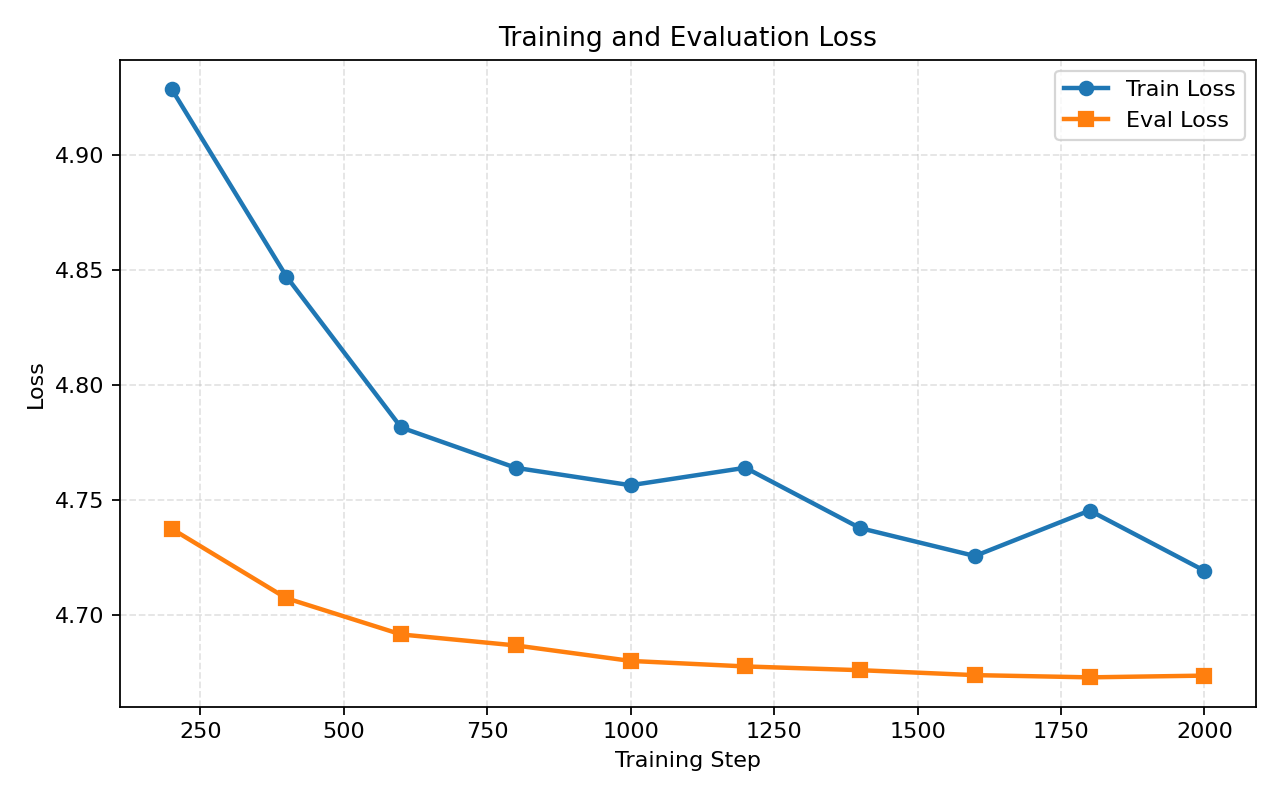

In [1]:
from TrainTools.train import train

results = train(
    # ── data paths (must match preprocess outputs) ──────────────────────
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model",
    log_dir         = "_log",

    # ── training loop ────────────────────────────────────────────────────
    num_steps  = 2000,
    batch_size = 16,
    seed       = 42,

    # ── vanilla recipe: SGD, no scheduler, NLL loss ───────────────────────
    optimizer_name = "sgd",
    scheduler_name = "none",
    loss_name      = "qa_nll",
)

print(f"Best F1: {results['best_f1']:.4f}  |  Best EM: {results['best_em']:.4f}")

from IPython.display import Image, display
display(Image(filename=results["loss_plot_path"]))

---
## Section 4 — Evaluate

Loads the saved checkpoint and runs inference on the full dev set.

In [2]:
from EvaluateTools.evaluate import evaluate

metrics = evaluate(
    dev_npz       = "_data/dev.npz",
    word_emb_json = "_data/word_emb.json",
    char_emb_json = "_data/char_emb.json",
    dev_eval_json = "_data/dev_eval.json",
    save_dir      = "_model",
    log_dir       = "_log",
    ckpt_name     = "model.pt",
)

print(f"F1: {metrics['f1']:.4f}  |  EM: {metrics['exact_match']:.4f}  |  Loss: {metrics['loss']:.6f}")

Using device: cuda:0 (NVIDIA vGPU-32GB)


/root/autodl-tmp/Assignment1_2026/EvaluateTools/evaluate.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)
100%|███████

TEST  loss 4.874101  F1 4.544866  EM 1.299570
F1: 4.5449  |  EM: 1.2996  |  Loss: 4.874101
